# Churn Prediction Model

**Objective:**

Build and compare multiple machine learning classification models to predict customer churn using customer demographics, financial attributes, and behavioral indicators.

The workflow follows a baseline-first approach:
- Prepare features and target
- Split the data
- Scale features where required
- Train multiple classification models
- Compare their performance using classification metrics

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score,recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

In [2]:
df= pd.read_csv("processed_data.csv")

In [3]:
df.head()

,creditscore,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,complain,satisfactionscore,pointearned,geography_Germany,geography_Spain,cardtype_GOLD,cardtype_PLATINUM,cardtype_SILVER
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,2,464,0,0,0,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1,3,456,0,1,0,0,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,3,377,0,0,0,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,5,350,0,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,5,425,0,1,1,0,0


In [4]:
#separating features and target
X= df.drop(columns='exited')
Y= df['exited']

#

1. Logistic Regression with all features intact:

In [5]:
#train-test split:

X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [6]:
#verifying stratification since data is imbalanced:
print(Y_train.value_counts(normalize=True))
print(Y_test.value_counts(normalize=True))

exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64
exited
0    0.796
1    0.204
Name: proportion, dtype: float64


In [7]:
#scaling features for logistic regression 
scaler= StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [8]:
#model object initialisation & training

logreg= LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [9]:
#y_hat/predictions:
y_pred= logreg.predict(X_test_scaled)

#churn probabilities:
y_prob= logreg.predict_proba(X_test_scaled)[:,1]
y_prob

array([1.04554996e-04, 1.04104609e-03, 3.15036271e-04, ...,
       6.06242528e-04, 9.95103632e-01, 4.73441373e-04], shape=(2000,))

In [10]:
pd.DataFrame({"Actual": Y_test.values, "Predicted": y_pred, "Churn Probability": y_prob}).head(10)

,Actual,Predicted,Churn Probability
0,0,0,0.000105
1,0,0,0.001041
2,0,0,0.000315
3,1,1,0.997784
4,0,0,0.001053
5,1,1,0.993162
6,1,1,0.993421
7,0,0,0.001021
8,0,0,0.000201
9,0,0,0.000478


In [11]:
#computing metrics:
print(f"Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"Precision: {precision_score(Y_test, y_pred):.4f}")
print(f"Recall: {recall_score(Y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(Y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(Y_test, y_prob):.4f}")

Accuracy: 0.9985
Precision: 0.9975
Recall: 0.9951
F1 Score: 0.9963
ROC-AUC: 0.9992


In [12]:
#storing results for future comparisons:
results= []
results.append({
    "Model": "Logistic Regression (all features)",
    "Accuracy": accuracy_score(Y_test, y_pred),
    "Precision": precision_score(Y_test, y_pred),
    "Recall": recall_score(Y_test, y_pred),
    "F1 Score": f1_score(Y_test, y_pred),
    "ROC-AUC": roc_auc_score(Y_test, y_prob)})


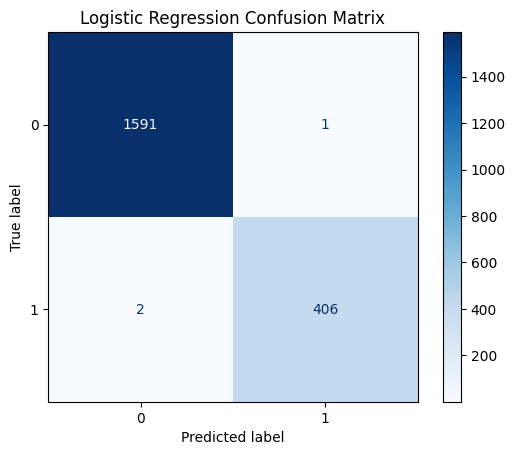

In [13]:
#confusion matrix:
cm= confusion_matrix(Y_test, y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [14]:
#comparing train & test performance (to check overfit)
train_pred = logreg.predict(X_train_scaled)
test_pred = logreg.predict(X_test_scaled)
print("Train Accuracy:", accuracy_score(Y_train, train_pred))
print("Test Accuracy:", accuracy_score(Y_test, test_pred))

Train Accuracy: 0.998625
Test Accuracy: 0.9985


- very accurate results, because feature 'complain' had direct correlation with churn. 
- training another model without feature 'complain'

#

2. No 'complain' feature Logistic Regression

In [15]:
X_no_complain= df.drop(columns=['exited', 'complain'])
y= df['exited']

#train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X_no_complain, Y, test_size=0.2, random_state=42, stratify=y)

#scaling
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

#training
logreg_no_complain= LogisticRegression(random_state=42, max_iter=1000)

logreg_no_complain.fit(X_train_scaled, Y_train)

# Predictions
y_pred= logreg_no_complain.predict(X_test_scaled)
y_prob= logreg_no_complain.predict_proba(X_test_scaled)[:,1]

In [16]:
print(f"Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"Precision: {precision_score(Y_test, y_pred):.4f}")
print(f"Recall: {recall_score(Y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(Y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(Y_test, y_prob):.4f}")

Accuracy: 0.8130
Precision: 0.6232
Recall: 0.2108
F1 Score: 0.3150
ROC-AUC: 0.7788


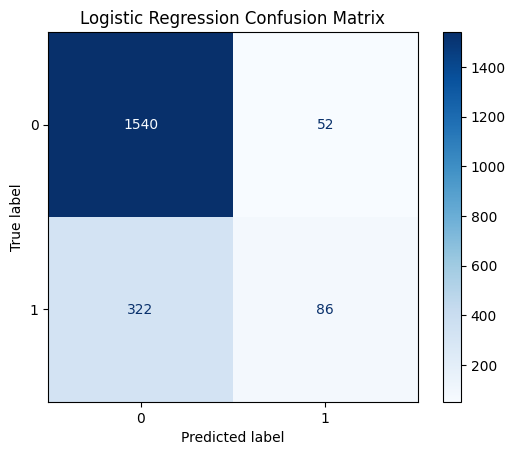

In [17]:
#confusion matrix:
cm= confusion_matrix(Y_test, y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [18]:
#storing results:
results.append({
    "Model": "Logistic Regression (without 'complain')",
    "Accuracy": accuracy_score(Y_test, y_pred),
    "Precision": precision_score(Y_test, y_pred),
    "Recall": recall_score(Y_test, y_pred),
    "F1 Score": f1_score(Y_test, y_pred),
    "ROC-AUC": roc_auc_score(Y_test, y_prob)})

#

3. Balanced + No 'complain' feature Logistic Regression

In [19]:
logreg_balanced= LogisticRegression(class_weight="balanced",random_state=42,max_iter=1000)

#training using previously scaled & splitted data:
logreg_balanced.fit(X_train_scaled, Y_train)

# Predictions
y_pred= logreg_balanced.predict(X_test_scaled)
y_prob= logreg_balanced.predict_proba(X_test_scaled)[:,1]

In [20]:
print(f"Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"Precision: {precision_score(Y_test, y_pred):.4f}")
print(f"Recall: {recall_score(Y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(Y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(Y_test, y_prob):.4f}")

Accuracy: 0.7130
Precision: 0.3902
Recall: 0.7230
F1 Score: 0.5069
ROC-AUC: 0.7802


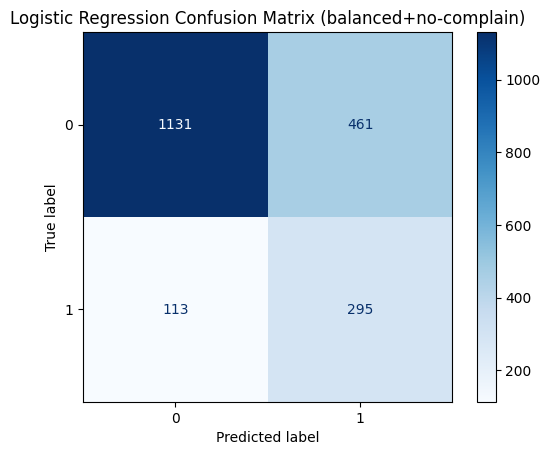

In [21]:
#confusion matrix:
cm= confusion_matrix(Y_test, y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix (balanced+no-complain)")
plt.show()

In [22]:
#storing results:
results.append({
    "Model": "Logistic Regression (without 'complain' + balanced)",
    "Accuracy": accuracy_score(Y_test, y_pred),
    "Precision": precision_score(Y_test, y_pred),
    "Recall": recall_score(Y_test, y_pred),
    "F1 Score": f1_score(Y_test, y_pred),
    "ROC-AUC": roc_auc_score(Y_test, y_prob)})

In [23]:
results_df= pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (all features),0.9985,0.997543,0.995098,0.996319,0.999246
1,Logistic Regression (without 'complain'),0.8130,0.623188,0.210784,0.315018,0.778839
2,Logistic Regression (without 'complain' + bala...,0.7130,0.390212,0.723039,0.506873,0.780151


##### Tree based algos:

4. Decision Tree:


In [24]:
dt= DecisionTreeClassifier(random_state=42,max_depth=5,min_samples_split=20,min_samples_leaf=10)
dt.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [25]:
#predictions:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

In [26]:
#metrics:
results.append({
    "Model": "Decision Tree (No 'complain')",
    "Accuracy": accuracy_score(Y_test, y_pred),
    "Precision": precision_score(Y_test, y_pred),
    "Recall": recall_score(Y_test, y_pred),
    "F1 Score": f1_score(Y_test, y_pred),
    "ROC-AUC": roc_auc_score(Y_test, y_prob)})

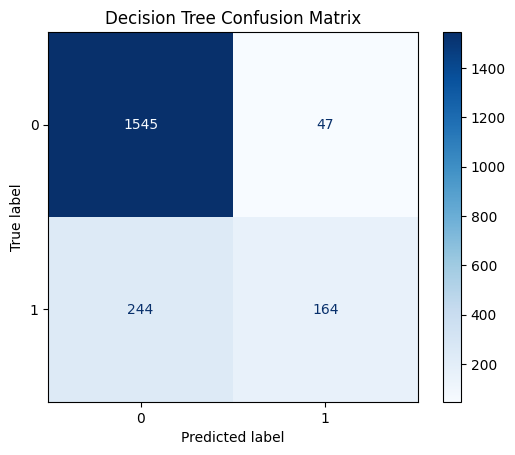

In [27]:
#confusion matrix:
cm= confusion_matrix(Y_test, y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [28]:
results_df= pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (all features),0.9985,0.997543,0.995098,0.996319,0.999246
1,Logistic Regression (without 'complain'),0.8130,0.623188,0.210784,0.315018,0.778839
2,Logistic Regression (without 'complain' + bala...,0.7130,0.390212,0.723039,0.506873,0.780151
3,Decision Tree (No 'complain'),0.8545,0.777251,0.401961,0.529887,0.851147


In [29]:
#checking feature importance:
feature_importance = pd.DataFrame({"Feature": X_train.columns,"Importance": dt.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance

,Feature,Importance
2,age,0.408576
5,numofproducts,0.331642
7,isactivemember,0.129414
11,geography_Germany,0.062553
4,balance,0.053340
8,estimatedsalary,0.008036
0,creditscore,0.002656
10,pointearned,0.001865
3,tenure,0.001093
1,gender,0.000825


5. Random Forest

In [30]:
rf = RandomForestClassifier(n_estimators=200,max_depth=8,min_samples_split=20,min_samples_leaf=10,random_state=42, n_jobs=-1)

rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [31]:
y_pred= rf.predict(X_test)
y_prob= rf.predict_proba(X_test)[:,1]

In [32]:
results.append({
    "Model": "Random Forest (No 'complain')",
    "Accuracy": accuracy_score(Y_test, y_pred),
    "Precision": precision_score(Y_test, y_pred),
    "Recall": recall_score(Y_test, y_pred),
    "F1 Score": f1_score(Y_test, y_pred),
    "ROC-AUC": roc_auc_score(Y_test, y_prob)})

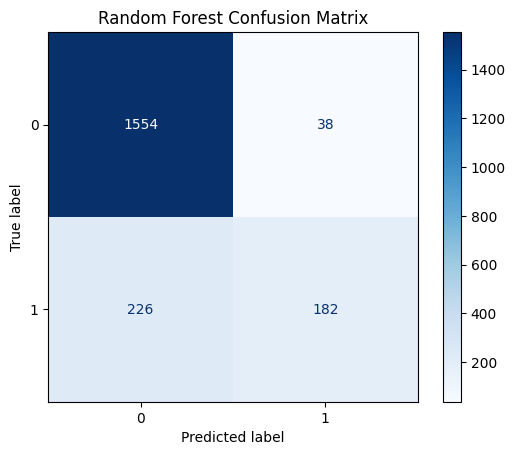

In [33]:
#confusion matrix:
cm= confusion_matrix(Y_test, y_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [34]:
results_df= pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (all features),0.9985,0.997543,0.995098,0.996319,0.999246
1,Logistic Regression (without 'complain'),0.8130,0.623188,0.210784,0.315018,0.778839
2,Logistic Regression (without 'complain' + bala...,0.7130,0.390212,0.723039,0.506873,0.780151
3,Decision Tree (No 'complain'),0.8545,0.777251,0.401961,0.529887,0.851147
4,Random Forest (No 'complain'),0.8680,0.827273,0.446078,0.579618,0.870290


In [35]:
#feature importance: 
feature_importance = pd.DataFrame({"Feature": X_train.columns,"Importance": rf.feature_importances_}).sort_values(by="Importance", ascending=False)
feature_importance

,Feature,Importance
2,age,0.363071
5,numofproducts,0.277603
7,isactivemember,0.076354
4,balance,0.074308
11,geography_Germany,0.060419
0,creditscore,0.033374
8,estimatedsalary,0.029087
10,pointearned,0.027523
1,gender,0.018059
3,tenure,0.014846


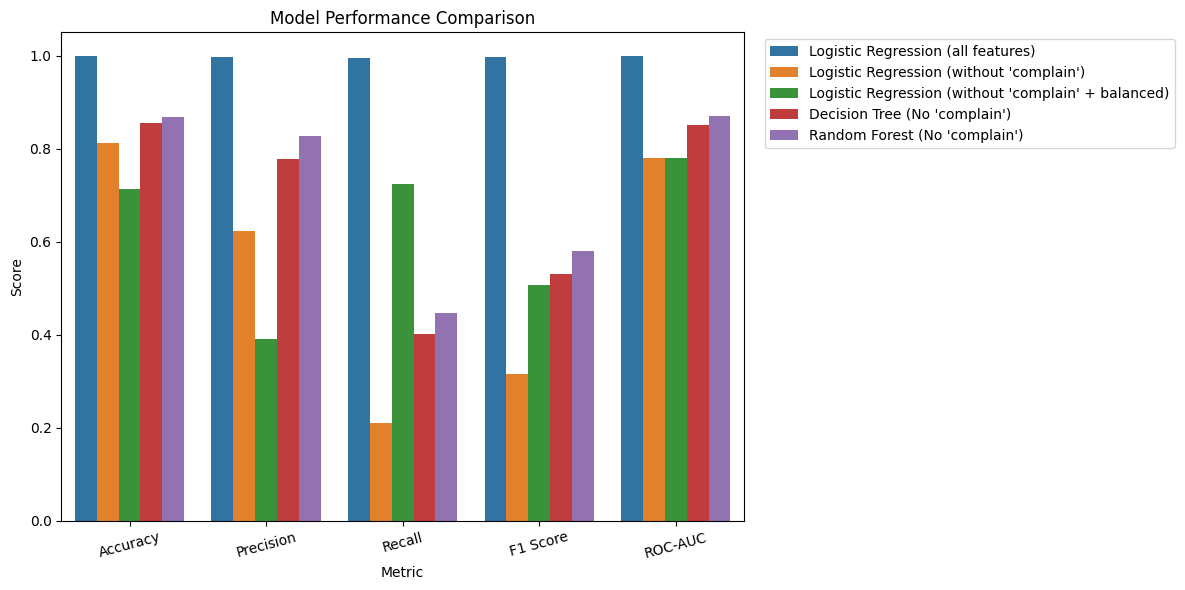

In [36]:
#comparing all models:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = results_df.melt(id_vars="Model", var_name="Metric",value_name="Score")
plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")

plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### SHAP ANALYSIS

In [38]:
import shap
explainer= shap.TreeExplainer(rf)
shap_values= explainer.shap_values(X_test)

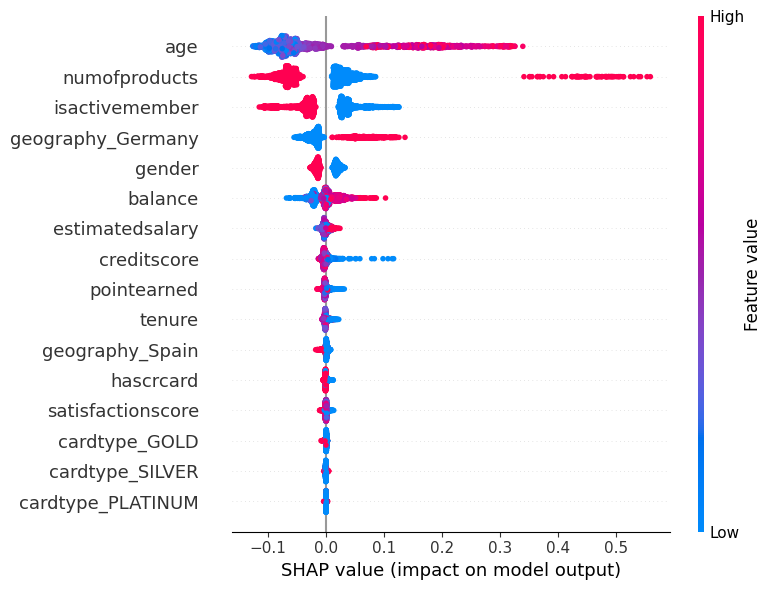

In [39]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_size=(8,6))

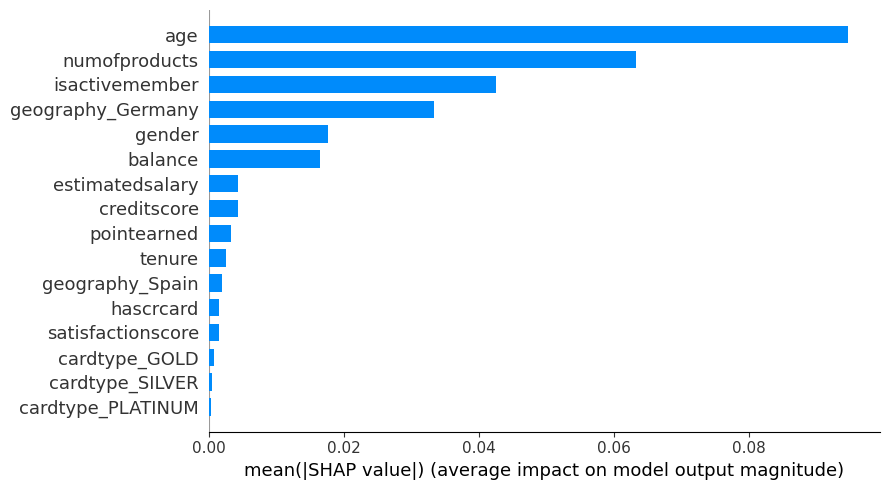

In [40]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", plot_size=(9,5))

In [42]:
df.groupby("numofproducts").agg(Customers=("exited", "count"),
          Churn_Rate=("exited", "mean")).assign(Churn_Rate=lambda x: x["Churn_Rate"] * 100)


,Customers,Churn_Rate
numofproducts,,
1,5084,27.714398
2,4590,7.603486
3,266,82.706767
4,60,100.000000


#### Risk Scoring

In [43]:
risk= pd.DataFrame({"Customer": X_test.index, "Churn Probability": y_prob})

risk["Risk Level"] = pd.cut(
    risk["Churn Probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low","Medium","High"]
)
risk["Risk Score"] = (risk["Churn Probability"]*100).round(0).astype(int)

In [44]:
risk.head()

,Customer,Churn Probability,Risk Level,Risk Score
0,6176,0.167149,Low,17
1,7072,0.136750,Low,14
2,877,0.112617,Low,11
3,6539,0.217139,Low,22
4,5190,0.055911,Low,6


### SUMMARY

Objective

Built a customer churn prediction pipeline to identify customers at high risk of leaving and understand the key factors driving churn.

**Workflow**
- Cleaned and encoded customer data
- Performed exploratory data analysis
- Built Logistic Regression, Decision Tree, and Random Forest models
- Compared models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC
- Used SHAP to explain model predictions
- Generated customer-level churn probabilities
- Converted probabilities into a 0–100 Risk Score and Low/Medium/High risk categories

**Key Findings**
- Complaint status is an almost perfect predictor of churn, making it unsuitable for early churn prediction.
- Age, number of products, active membership, account balance, and geography were the strongest predictors.
- Random Forest outperformed Decision Tree when complaint data was excluded.
- SHAP explanations aligned with patterns previously discovered through SQL analysis.
- Customers can now be prioritized for retention using risk scores instead of binary predictions.

Instead of simply predicting churn, this project produces an interpretable customer risk scoring system that can help retention teams prioritize intervention campaigns.

#

#### exporting data for powerbi:

In [47]:
cust_id_df= pd.read_csv("bank_customers.csv")

In [48]:
customer_ids=  cust_id_df["customerid"]

In [49]:
predictions = X_test.copy()

predictions["Actual Churn"] = Y_test.values
predictions["Prediction"] = y_pred
predictions["Churn Probability"] = y_prob

predictions["Risk Score"] = (
    predictions["Churn Probability"] * 100
).round().astype(int)

predictions["Risk Level"] = pd.cut(
    predictions["Churn Probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low","Medium","High"]
)

In [50]:
def action(score):

    if score >= 80:
        return "Immediate Retention Call"

    elif score >= 60:
        return "Personalized Offer"

    elif score >= 30:
        return "Monitor"

    else:
        return "Routine Engagement"

predictions["Suggested Action"] = predictions["Risk Score"].apply(action)

In [51]:
predictions.insert(0,"Customerid", customer_ids.loc[predictions.index].values)

In [52]:
predictions.head(2)

,Customerid,creditscore,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,...,geography_Spain,cardtype_GOLD,cardtype_PLATINUM,cardtype_SILVER,Actual Churn,Prediction,Churn Probability,Risk Score,Risk Level,Suggested Action
6176,15604146,608,0,38,8,103653.51,2,1,1,137079.86,...,0,0,0,1,0,0,0.167149,17,Low,Routine Engagement
7072,15775750,686,1,37,9,134560.62,1,1,0,27596.39,...,0,0,0,0,0,0,0.136750,14,Low,Routine Engagement


In [53]:
predictions.to_csv("customer_predictions.csv",index=False)

#### Saving the model for application:

In [54]:
import joblib

In [55]:
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [56]:
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']